In [7]:
import pandas as pd
from pandas.core.dtypes.common import is_numeric_dtype

df = pd.read_csv("cleaned_data.csv")
max(df["smokingyears"])

for column in df.columns:
    if is_numeric_dtype(df[column]):
        print("Max value is ", max(df[column]), " in column ", column)
    else:
        print(column, "is not numeric")
        


Max value is  799  in column  id
gender is not numeric
Max value is  77  in column  age
Max value is  3.0  in column  race
Max value is  48.1  in column  bmi
marital_status is not numeric
Max value is  2  in column  typediabetes
Max value is  40.0  in column  duration_of_diabetes_years
Max value is  80  in column  smokingyears
Max value is  1  in column  amputation
Max value is  300  in column  sysbp
Max value is  100  in column  diabp
Max value is  12.2  in column  hba1c
Max value is  73.3  in column  hdl
Max value is  9.9  in column  ldl
Max value is  986.75  in column  tri
Max value is  10.0  in column  serumcre
Max value is  nan  in column  microalb
Max value is  4.8  in column  serumalb
hypoglycemic_agents is not numeric
Max value is  1  in column  medication_insulin
Max value is  1  in column  medication_sulfonylureas
Max value is  1  in column  medication_bp
diabetic_macrovascular_complications is not numeric
diabetic_microvascular_complications is not numeric
comorbidities is n

In [8]:
print(df[df["smokingyears"] == df["smokingyears"].max()])

     id gender  age  race   bmi marital_status  typediabetes  \
32  650      M   36   1.0  23.0         single             2   

    duration_of_diabetes_years  smokingyears  amputation  ...  serumcre  \
32                        10.0            80           0  ...       0.8   

    microalb  serumalb              hypoglycemic_agents  medication_insulin  \
32       NaN       4.5  insulin aspart 70/30 | acarbose                   0   

    medication_sulfonylureas  medication_bp  \
32                         1              0   

                 diabetic_macrovascular_complications  \
32  peripheral arterial disease | cerebrovascular ...   

      diabetic_microvascular_complications  \
32  nephropathy | neuropathy | retinopathy   

                                        comorbidities  
32  hypertension | hypertension | hyperuricemia | ...  

[1 rows x 26 columns]


In [9]:
logic_errors= 0
for index, row in df.iterrows():
    if row["age"] <= row["smokingyears"]:
        print("Logig error in ", row.values)
        logic_errors += 1
logic_errors

Logig error in  [494 'M' 30 2.0 29.1 'single' 2 4.0 30 0 208 65 5.7 29.0 3.5 151.0 8.2
 19.9 nan 'insulin detemir | acarbose | metformin' 0 0 0
 'peripheral arterial disease' nan
 'hepatic dysfunction | hyperlipidemia | fatty liver disease | liver cyst | gallbladder polyp | thyroid nodule']
Logig error in  [106 'F' 44 1.0 38.8 'single' 2 20.0 60 0 219 73 5.8 41.0 3.6 95.0 1.4 nan
 nan 'Novolin R | insulin glarigine' 0 1 0 'coronary heart disease'
 'retinopathy' nan]
Logig error in  [650 'M' 36 1.0 23.0 'single' 2 10.0 80 0 181 64 5.9 45.5 1.9 89.0 0.8 nan
 4.5 'insulin aspart 70/30 | acarbose' 0 1 0
 'peripheral arterial disease | cerebrovascular disease'
 'nephropathy | neuropathy | retinopathy'
 'hypertension | hypertension | hyperuricemia | hyperlipidemia | thyroid nodule | vitamin d deficiency | pulmonary nodule | fatty liver disease | cholelithiasis | prostatic hyperplasia']


3

In [10]:
df.isnull().sum()

id                                        0
gender                                    4
age                                       0
race                                      2
bmi                                       0
marital_status                            6
typediabetes                              0
duration_of_diabetes_years              176
smokingyears                              0
amputation                                0
sysbp                                     0
diabp                                     0
hba1c                                     0
hdl                                      11
ldl                                       1
tri                                      12
serumcre                                 12
microalb                                206
serumalb                                101
hypoglycemic_agents                     139
medication_insulin                        0
medication_sulfonylureas                  0
medication_bp                   

In [11]:
print(min(df["duration_of_diabetes_years"]))

0.0


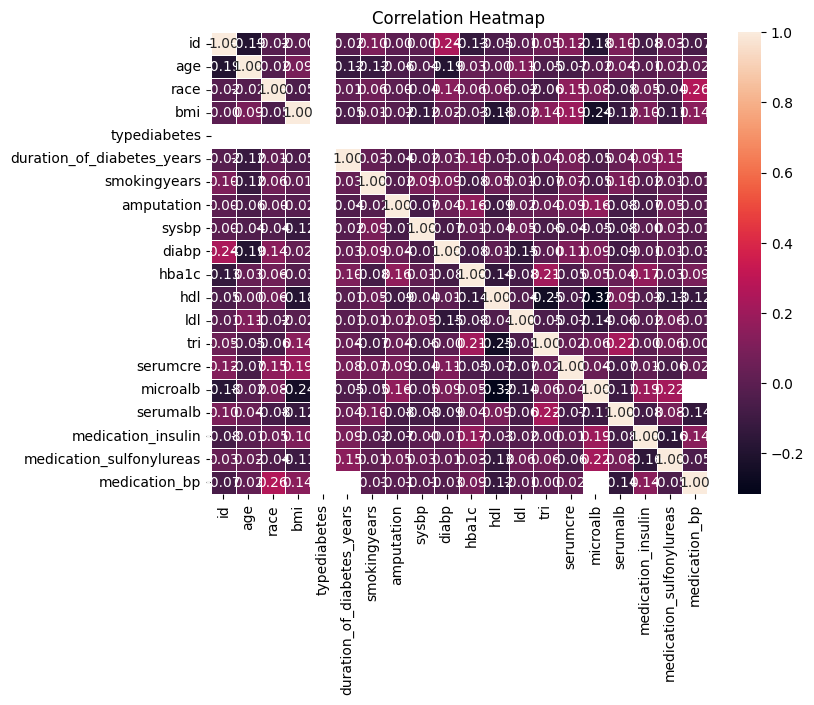

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

matrix = df.select_dtypes(include='number').corr()

plt.figure(figsize=(8,6))
sns.heatmap(matrix, annot=True, fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()